In [1]:
# pip install pandas matplotlib seaborn scikit-learn openpyxl
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Load the data and clean it
df = pd.read_excel('online_retail_data/Online Retail.xlsx', parse_dates=['InvoiceDate'])

print(df.shape)  
print(df.head())
print(df.isnull().sum())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
d

In [3]:
# Eliminate records with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# make sure CustomerID is an integer
df['CustomerID'] = df['CustomerID'].astype(int)

# Remove cancellations (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero quantities
df = df[df['Quantity'] > 0]

# Remove zero or negative unit prices (free items / data errors)
df = df[df['UnitPrice'] > 0] 

# Create a revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# check the data
print(df.shape)  

(397884, 9)


In [4]:
# Remove cancellations (InvoiceNo starting with 'C')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
# get count of records in the dataframe: 897844
len(df)

397884

In [6]:
# Set reference date as day after last transaction
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm3 = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')    
).reset_index()

print(rfm3.head())
print(rfm3.describe())

   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


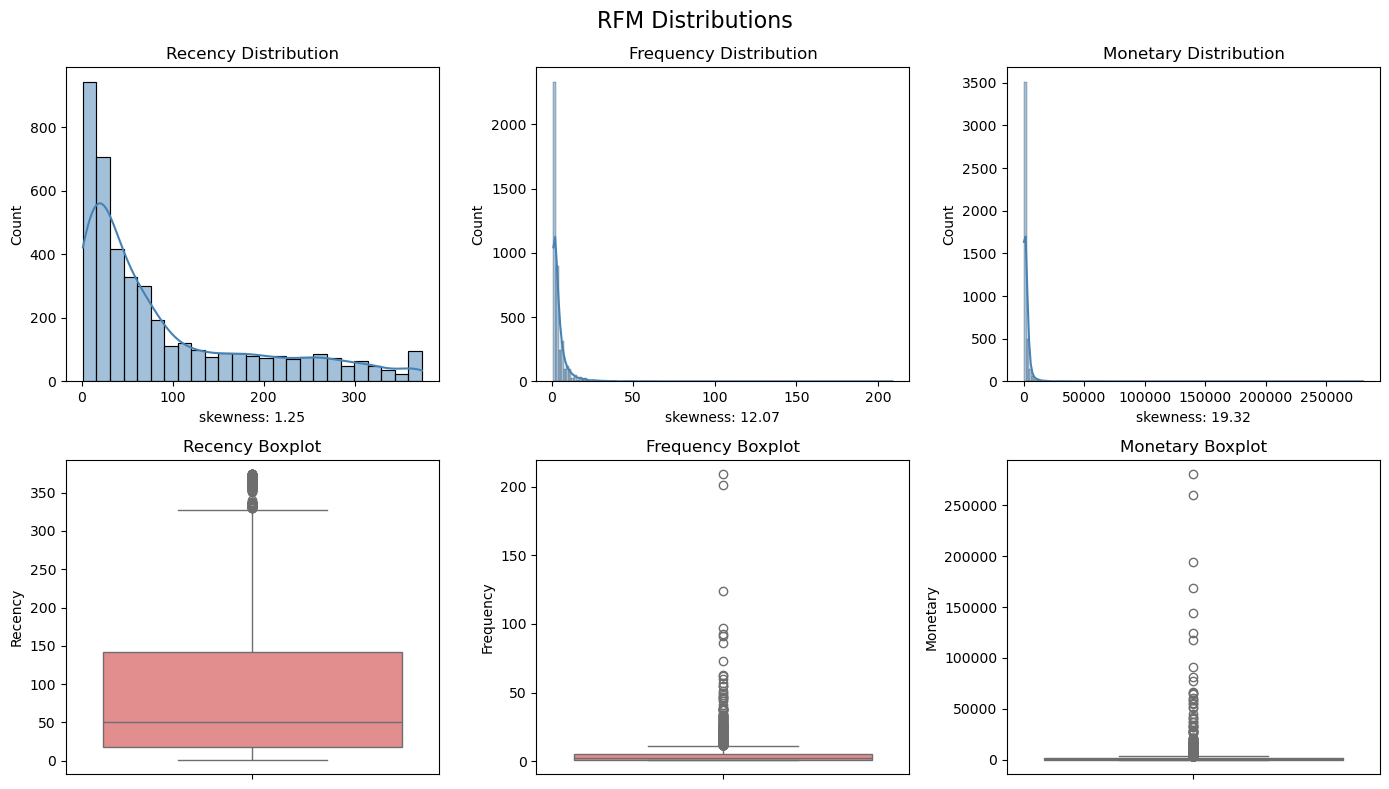

In [7]:
# Check for skewness in the RFM variables
# This cell will display plots to visualize the distribution of Recency, Frequency, and Monetary values, along with their skewness.

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('RFM Distributions', fontsize=16)

cols = ['Recency', 'Frequency', 'Monetary']

# Row 1: Histograms with KDE
for i, col in enumerate(cols):
    sns.histplot(rfm3[col], kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'{col} Distribution')
    skew_val = rfm3[col].skew()
    axes[0, i].set_xlabel(f'skewness: {skew_val:.2f}')

# Row 2: Box plots (shows outliers clearly)
for i, col in enumerate(cols):
    sns.boxplot(y=rfm3[col], ax=axes[1, i], color='lightcoral')
    axes[1, i].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

In [8]:
# Our RFM data is skewed, so we can log-transform it to make it more normal
# K-Means is sensitive to skewness, so this can help improve the clustering results
rfm3_log = rfm3[['Recency', 'Frequency', 'Monetary']].copy()

rfm3_log['Recency']   = np.log1p(rfm3_log['Recency'])
rfm3_log['Frequency'] = np.log1p(rfm3_log['Frequency'])
rfm3_log['Monetary']  = np.log1p(rfm3_log['Monetary'])

# Scale so all features are on the same range
scaler = StandardScaler()
rfm3_scaled = scaler.fit_transform(rfm3_log)

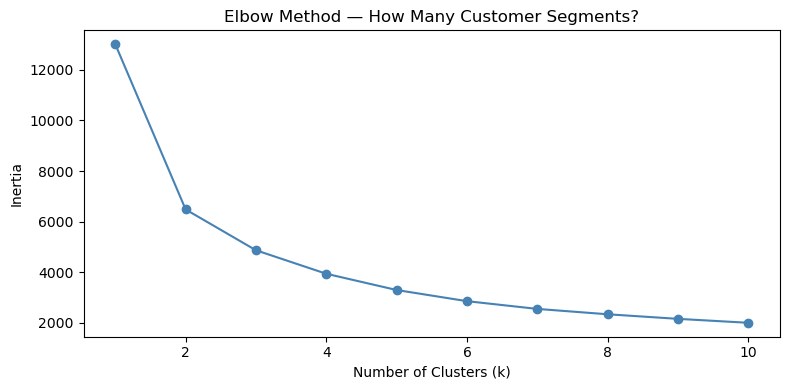

In [9]:
# Find the optimal number of clusters using the Elbow Method
# here k will either be 3 or 4 based on this data
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm3_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — How Many Customer Segments?')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()  
plt.show()

In [10]:
# Run with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm3['Cluster'] = kmeans.fit_predict(rfm3_scaled)

rfm3['Cluster'] = rfm3['Cluster'].astype(str)

# Get the average profile of each segment
summary3 = rfm3.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print(summary3)

         Recency  Frequency  Monetary
Cluster                              
0           17.1       13.3    7905.4
1          167.4        1.4     362.5
2           44.2        3.4    1265.1


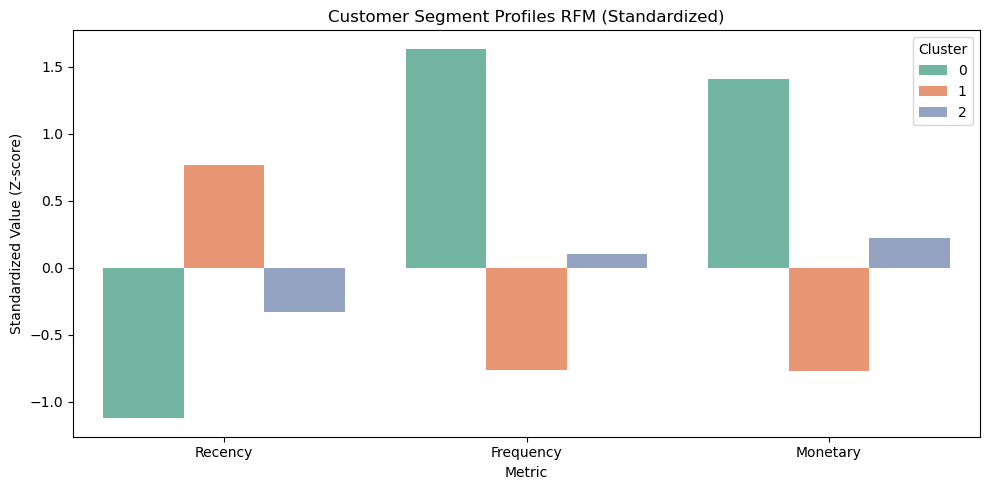

In [11]:
rfm3_scaled_df = pd.DataFrame(rfm3_scaled, columns=['Recency', 'Frequency', 'Monetary'])

rfm3_scaled_df['Cluster'] = rfm3['Cluster'].values

cluster_profile = rfm3_scaled_df.groupby('Cluster').mean().reset_index()

rfm3_melt = cluster_profile.melt(id_vars='Cluster', var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 5))
sns.barplot(data=rfm3_melt, x='Metric', y='Value', hue='Cluster', palette='Set2')
plt.title('Customer Segment Profiles RFM (Standardized)')
plt.ylabel('Standardized Value (Z-score)')
plt.tight_layout()
plt.show()

In [12]:
# Adding Average Order Value to the RFM calculation
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm4 = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')    
).reset_index()

rfm4['AveOrderValue'] = rfm4['Monetary'] / rfm4['Frequency']

print(rfm4.head())
print(rfm4.describe())

   CustomerID  Recency  Frequency  Monetary  AveOrderValue
0       12346      326          1  77183.60   77183.600000
1       12347        2          7   4310.00     615.714286
2       12348       75          4   1797.24     449.310000
3       12349       19          1   1757.55    1757.550000
4       12350      310          1    334.40     334.400000
         CustomerID      Recency    Frequency       Monetary  AveOrderValue
count   4338.000000  4338.000000  4338.000000    4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460     419.166289
std     1721.808492   100.014169     7.697998    8989.230441    1796.537944
min    12346.000000     1.000000     1.000000       3.750000       3.450000
25%    13813.250000    18.000000     1.000000     307.415000     178.625000
50%    15299.500000    51.000000     2.000000     674.485000     293.900000
75%    16778.750000   142.000000     5.000000    1661.740000     430.113750
max    18287.000000   374.000000   209

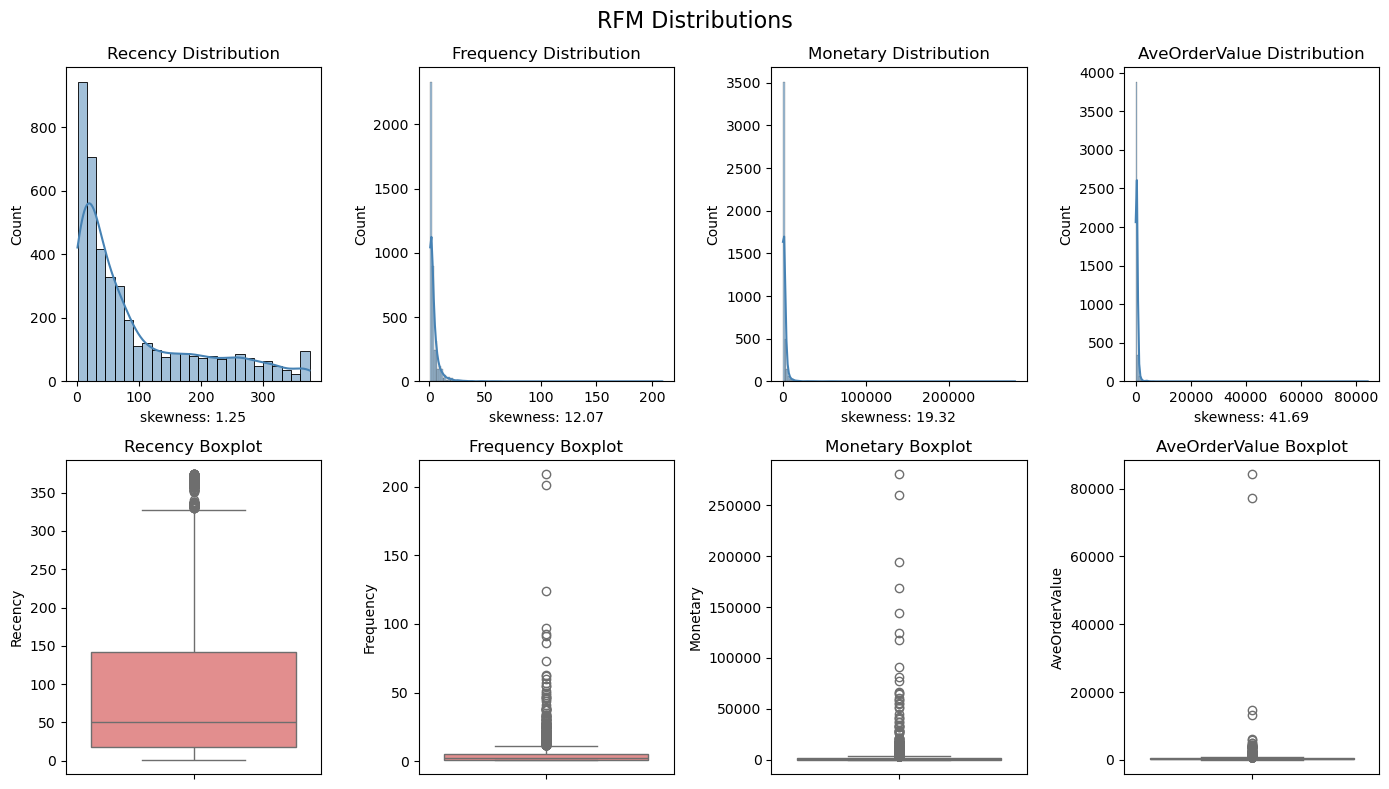

In [13]:
# Check for skewness in the RFM variables
# This cell will display plots to visualize the distribution of Recency, Frequency, Monetary, and Average Order Value values, along with their skewness.

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
fig.suptitle('RFM Distributions', fontsize=16)

cols = ['Recency', 'Frequency', 'Monetary', 'AveOrderValue']

# Row 1: Histograms with KDE
for i, col in enumerate(cols):
    sns.histplot(rfm4[col], kde=True, ax=axes[0, i], color='steelblue')
    axes[0, i].set_title(f'{col} Distribution')
    skew_val = rfm4[col].skew()
    axes[0, i].set_xlabel(f'skewness: {skew_val:.2f}')

# Row 2: Box plots (shows outliers clearly)
for i, col in enumerate(cols):
    sns.boxplot(y=rfm4[col], ax=axes[1, i], color='lightcoral')
    axes[1, i].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

In [14]:
# Our RFM data is skewed, so we can log-transform it to make it more normal
# K-Means is sensitive to skewness, so this can help improve the clustering results
rfm4_log = rfm4[['Recency', 'Frequency', 'Monetary', 'AveOrderValue']].copy()

rfm4_log['Recency']   = np.log1p(rfm4_log['Recency'])
rfm4_log['Frequency'] = np.log1p(rfm4_log['Frequency'])
rfm4_log['Monetary']  = np.log1p(rfm4_log['Monetary'])
rfm4_log['AveOrderValue'] = np.log1p(rfm4_log['AveOrderValue'])
# Scale so all features are on the same range
scaler = StandardScaler()
rfm4_scaled = scaler.fit_transform(rfm4_log)

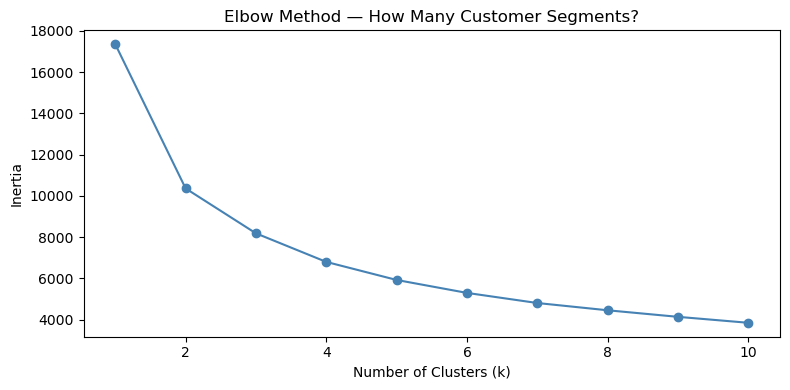

In [15]:
# Find the optimal number of clusters using the Elbow Method
# here k will either be 3 or 4 based on this data
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm4_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — How Many Customer Segments?')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()  
plt.show()

In [16]:
# Run with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm4['Cluster'] = kmeans.fit_predict(rfm4_scaled)

rfm4['Cluster'] = rfm4['Cluster'].astype(str)

# Get the average profile of each segment
summary = rfm4.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'AveOrderValue']].mean().round(1)
print(summary)

         Recency  Frequency  Monetary  AveOrderValue
Cluster                                             
0           19.6        9.9    5318.8          520.9
1          136.7        1.7     245.0          149.9
2          112.3        2.1    1033.8          561.7


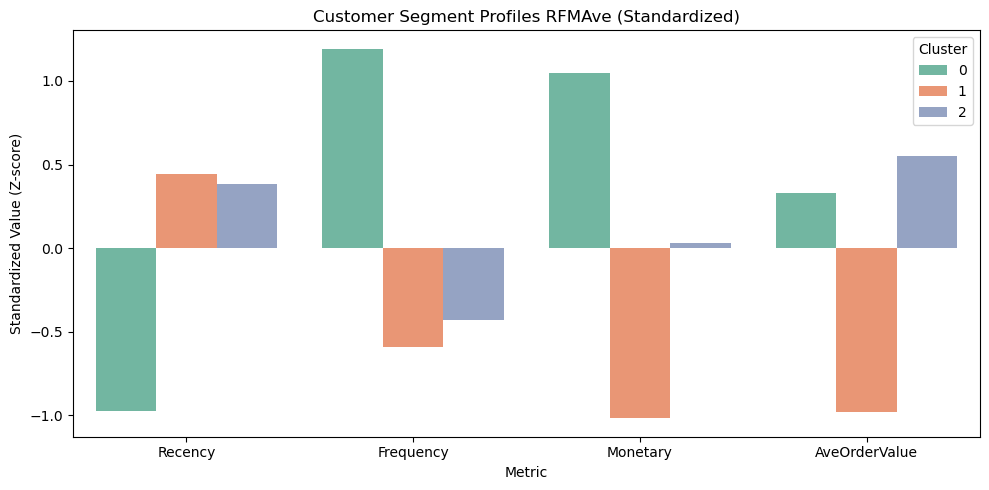

In [17]:
rfm4_scaled_df = pd.DataFrame(rfm4_scaled, columns=['Recency', 'Frequency', 'Monetary', 'AveOrderValue'])

rfm4_scaled_df['Cluster'] = rfm4['Cluster'].values

cluster_profile = rfm4_scaled_df.groupby('Cluster').mean().reset_index()

rfm4_melt = cluster_profile.melt(id_vars='Cluster', var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 5))
sns.barplot(data=rfm4_melt, x='Metric', y='Value', hue='Cluster', palette='Set2')
plt.title('Customer Segment Profiles RFMAve (Standardized)')
plt.ylabel('Standardized Value (Z-score)')
plt.tight_layout()
plt.show()